torch.Size([32, 3, 28, 28])
torch.Size([32])
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 64, 26, 26]           1,792
         MaxPool2d-2           [-1, 64, 13, 13]               0
              ReLU-3           [-1, 64, 13, 13]               0
            Conv2d-4          [-1, 128, 11, 11]          73,856
         MaxPool2d-5            [-1, 128, 5, 5]               0
              ReLU-6            [-1, 128, 5, 5]               0
           Flatten-7                 [-1, 3200]               0
            Linear-8                  [-1, 512]       1,638,912
              ReLU-9                  [-1, 512]               0
           Linear-10                  [-1, 256]         131,328
             ReLU-11                  [-1, 256]               0
           Linear-12                  [-1, 128]          32,896
             ReLU-13                  [-1, 128]           

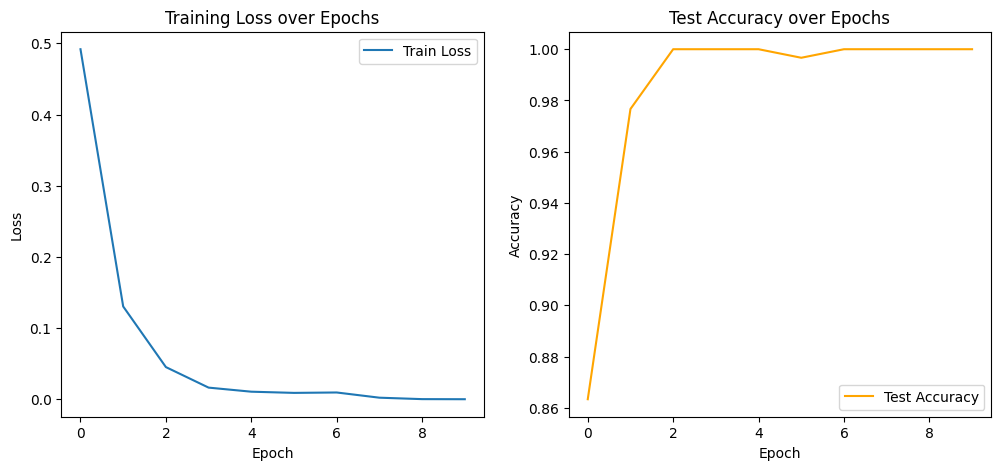

In [45]:
from matplotlib import pyplot as plt
from torchvision import datasets, transforms
import torch
import torch.nn as nn
from torch.utils.data import Dataset
import torch.optim as optim
import numpy as np
from glob import glob
from torchsummary import summary
import os


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

path_train = "training_data_sm/train_data"
path_test = "training_data_sm/test_data"

tfm = transforms.Compose([
    transforms.Resize((28,28)),
    transforms.ToTensor()
])
data_train = datasets.ImageFolder(path_train, transform=tfm)
data_test = datasets.ImageFolder(path_test, transform=tfm)

# print(len(data_train))
# print(len(data_test))

train_loader = torch.utils.data.DataLoader(data_train, batch_size=32, shuffle=True)
test_loader = torch.utils.data.DataLoader(data_test, batch_size=32, shuffle=False)

for i, data in enumerate(train_loader):
    images, labels = data
    print(images.shape)
    print(labels.shape)
    break


class XO(Dataset):
    def __init__(self, data_type='train'):
        super().__init__()
        
        # 根据data_type参数选择是加载训练数据还是测试数据
        if data_type == 'train':
            data_path = "training_data_sm/train_data"
        elif data_type == 'test':
            data_path = "training_data_sm/test_data"
        else:
            raise ValueError("data_type must be 'train' or 'test'")
        
        # 获取所有圆形和十字形图像的路径
        circles_path = os.path.join(data_path, "circles_sm", "*.bmp")
        crosses_path = os.path.join(data_path, "crosses_sm", "*.bmp")
        
        # 加载所有图像路径
        circle_files = glob(circles_path)
        cross_files = glob(crosses_path)
        
        # 创建数据列表，包含图像路径和对应的标签
        # 圆形为标签0，十字形为标签1
        self.data = []
        for file in circle_files:
            self.data.append((file, 0))
        for file in cross_files:
            self.data.append((file, 1))
        
        # 定义图像变换
        self.transform = transforms.Compose([
            transforms.ToTensor(),        # 转换为张量
            transforms.Grayscale(num_output_channels=1)  # 转换为单通道灰度图
        ])
    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, index):
        # 获取图像路径和标签
        img_path, label = self.data[index]
        img = Image.open(img_path).convert('L')  # 转换为灰度图
        if self.transform:
            img = self.transform(img)
        return img, label
    
class MyNet(nn.Module):
    def __init__(self):
        super(MyNet, self).__init__()
        self.model = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=64, kernel_size=3),
            nn.MaxPool2d(2),
            nn.ReLU(),
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3),
            nn.MaxPool2d(2),
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(128 * 5 * 5, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 1),
            nn.Sigmoid()
        ).to(device)
        
    def forward(self, x):
        x = x.to(device)
        return self.model(x)
    
def train(model, train_loader, criterion, optimizer):
    model.train()
    running_loss = 0.0
    for i, data in enumerate(train_loader):
        inputs, labels = data
        inputs, labels = inputs.to(device), labels.to(device).float().view(-1,1)
        
        optimizer.zero_grad()
        
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        
    return running_loss / len(train_loader)

def test(model, test_loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for data in test_loader:
            images, labels = data
            images, labels = images.to(device), labels.to(device).float().view(-1,1)
            outputs = model(images)
            predicted = (outputs > 0.5).float()
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return correct / total

summary(MyNet().to(device), (3, 28, 28))

if __name__ == "__main__":
    model = MyNet().to(device)
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    num_epochs = 10
    train_losses = []
    test_accuracies = []
    for epoch in range(num_epochs):
        train_loss = train(model, train_loader, criterion, optimizer)
        test_accuracy = test(model, test_loader)
        train_losses.append(train_loss)
        test_accuracies.append(test_accuracy)
        print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss:.4f}, Test Accuracy: {test_accuracy:.4f}")
    plt.figure(figsize=(12,5))
    plt.subplot(1,2,1)
    plt.plot(train_losses, label='Train Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training Loss over Epochs')
    plt.legend()
    plt.subplot(1,2,2)
    plt.plot(test_accuracies, label='Test Accuracy', color='orange')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title('Test Accuracy over Epochs')
    plt.legend()
    plt.show()
    torch.save(model.state_dict(), 'model.pth')
    


In [5]:
import torch
import torch.nn as nn
import cv2
import numpy as np
import torchvision.transforms as transforms


class MyNet(nn.Module):
    def __init__(self):
        super(MyNet, self).__init__()
        self.model = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=64, kernel_size=3),
            nn.MaxPool2d(2),
            nn.ReLU(),
            nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3),
            nn.MaxPool2d(2),
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(128 * 5 * 5, 512),
            nn.ReLU(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 1),
            nn.Sigmoid()
        ).to(device)
    def forward(self, x):
        x = x.to(device)
        return self.model(x)    


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = MyNet().to(device)
model.load_state_dict(torch.load('model.pth', map_location=device))
x = cv2.imread('training_data_sm/test_data/crosses_sm/cr130.bmp')
x = cv2.cvtColor(x, cv2.COLOR_BGR2RGB)
x = cv2.resize(x, (28,28))
x = torch.from_numpy(x).permute(2, 0, 1).unsqueeze(0).float()/255.0
print(x.shape)
x = x.to(device)

y = model(x)
if y > 0.5:
    print('X')
else:
    print('C')


torch.Size([1, 3, 28, 28])
X


C:\Users\Administrator\AppData\Local\Temp\ipykernel_23836\3587940189.py:35: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('model.pth', map_l

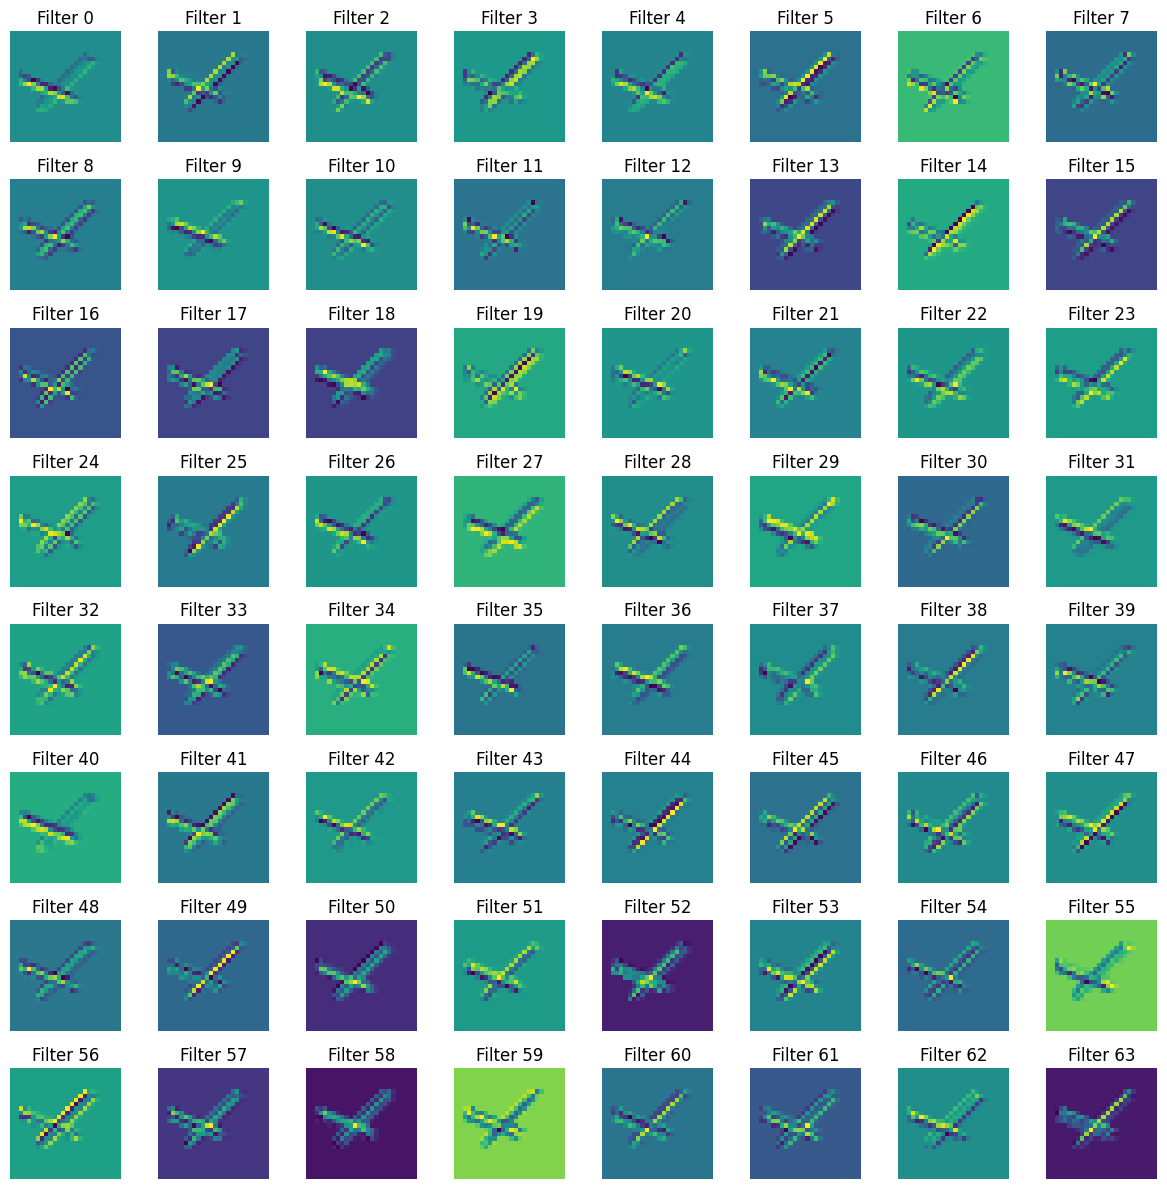

In [22]:
from matplotlib.pyplot import subplots
import torch
import torch.nn as nn
import cv2
import numpy as np
import torchvision.transforms as transforms


# print(*list(model.children()))
# print(x.shape)
first_layer = list(model.children())[0][0]
# print(first_layer)
with torch.no_grad():
    output_first = first_layer(x)
    
# print(output_first)
features = output_first[0].detach().cpu().numpy()
# print(features)
fig, ax = subplots(8,8,figsize=(12,12))
for i, axix in enumerate(ax.flat):
    axix.imshow(features[i])
    axix.set_title(f'Filter {i}')
    axix.axis('off')
plt.tight_layout()
plt.show()